<a href="https://colab.research.google.com/github/lawesworks/vision-model-workbench/blob/main/YOLO-OD-Trainer-Hands-On-Basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Load Roboflow API Key
# Retrieves the Roboflow API key that you've set in Google Colab's Secrets
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

from google.colab import userdata
api_key = userdata.get('ROBOFLOW_API_KEY')

if api_key is None:
    raise ValueError("ROBOFLOW_API_KEY not found. Check Colab Secrets.")

print("Roboflow API Key Found")

In [ ]:
!pip install -q roboflow ultralytics

In [ ]:
# Import the Dataset you'll use to train your model

from roboflow import Roboflow
import os

rf = Roboflow(api_key=api_key)
project = rf.workspace("-jwzpw").project("continuous_fire")
dataset = project.version(1).download("yolov8")  # adjust version if needed

In [4]:

# get location of the yaml file, you'll copy an paste it into the next cell

import glob, os

yaml_files = glob.glob("/content/**/data.yaml", recursive=True)
yaml_files

['/content/continuous_fire-1/data.yaml']

In [ ]:
# train your model on the data
# prior to training, you might want to make sure you are connected to a GPU
# adjust your epochs as needed.  More epocs more = More training time

from ultralytics import YOLO

DATA_YAML_PATH = "/content/continuous_fire-1/data.yaml"

model = YOLO("yolov8n.pt")  # small + fast starter model
results = model.train(
    data=DATA_YAML_PATH,
    epochs=5,
    imgsz=640,
    batch=16
)


In [ ]:
# get location of the weights for the latest training

import glob
glob.glob("runs/detect/train*/weights/best.pt")

In [ ]:
# run the model against the test data in your project

best_model_path = glob.glob("runs/detect/train/weights/best.pt")[-1]
model = YOLO(best_model_path)

model.predict(source="continuous_fire-1/test/images", save=True, conf=0.25)


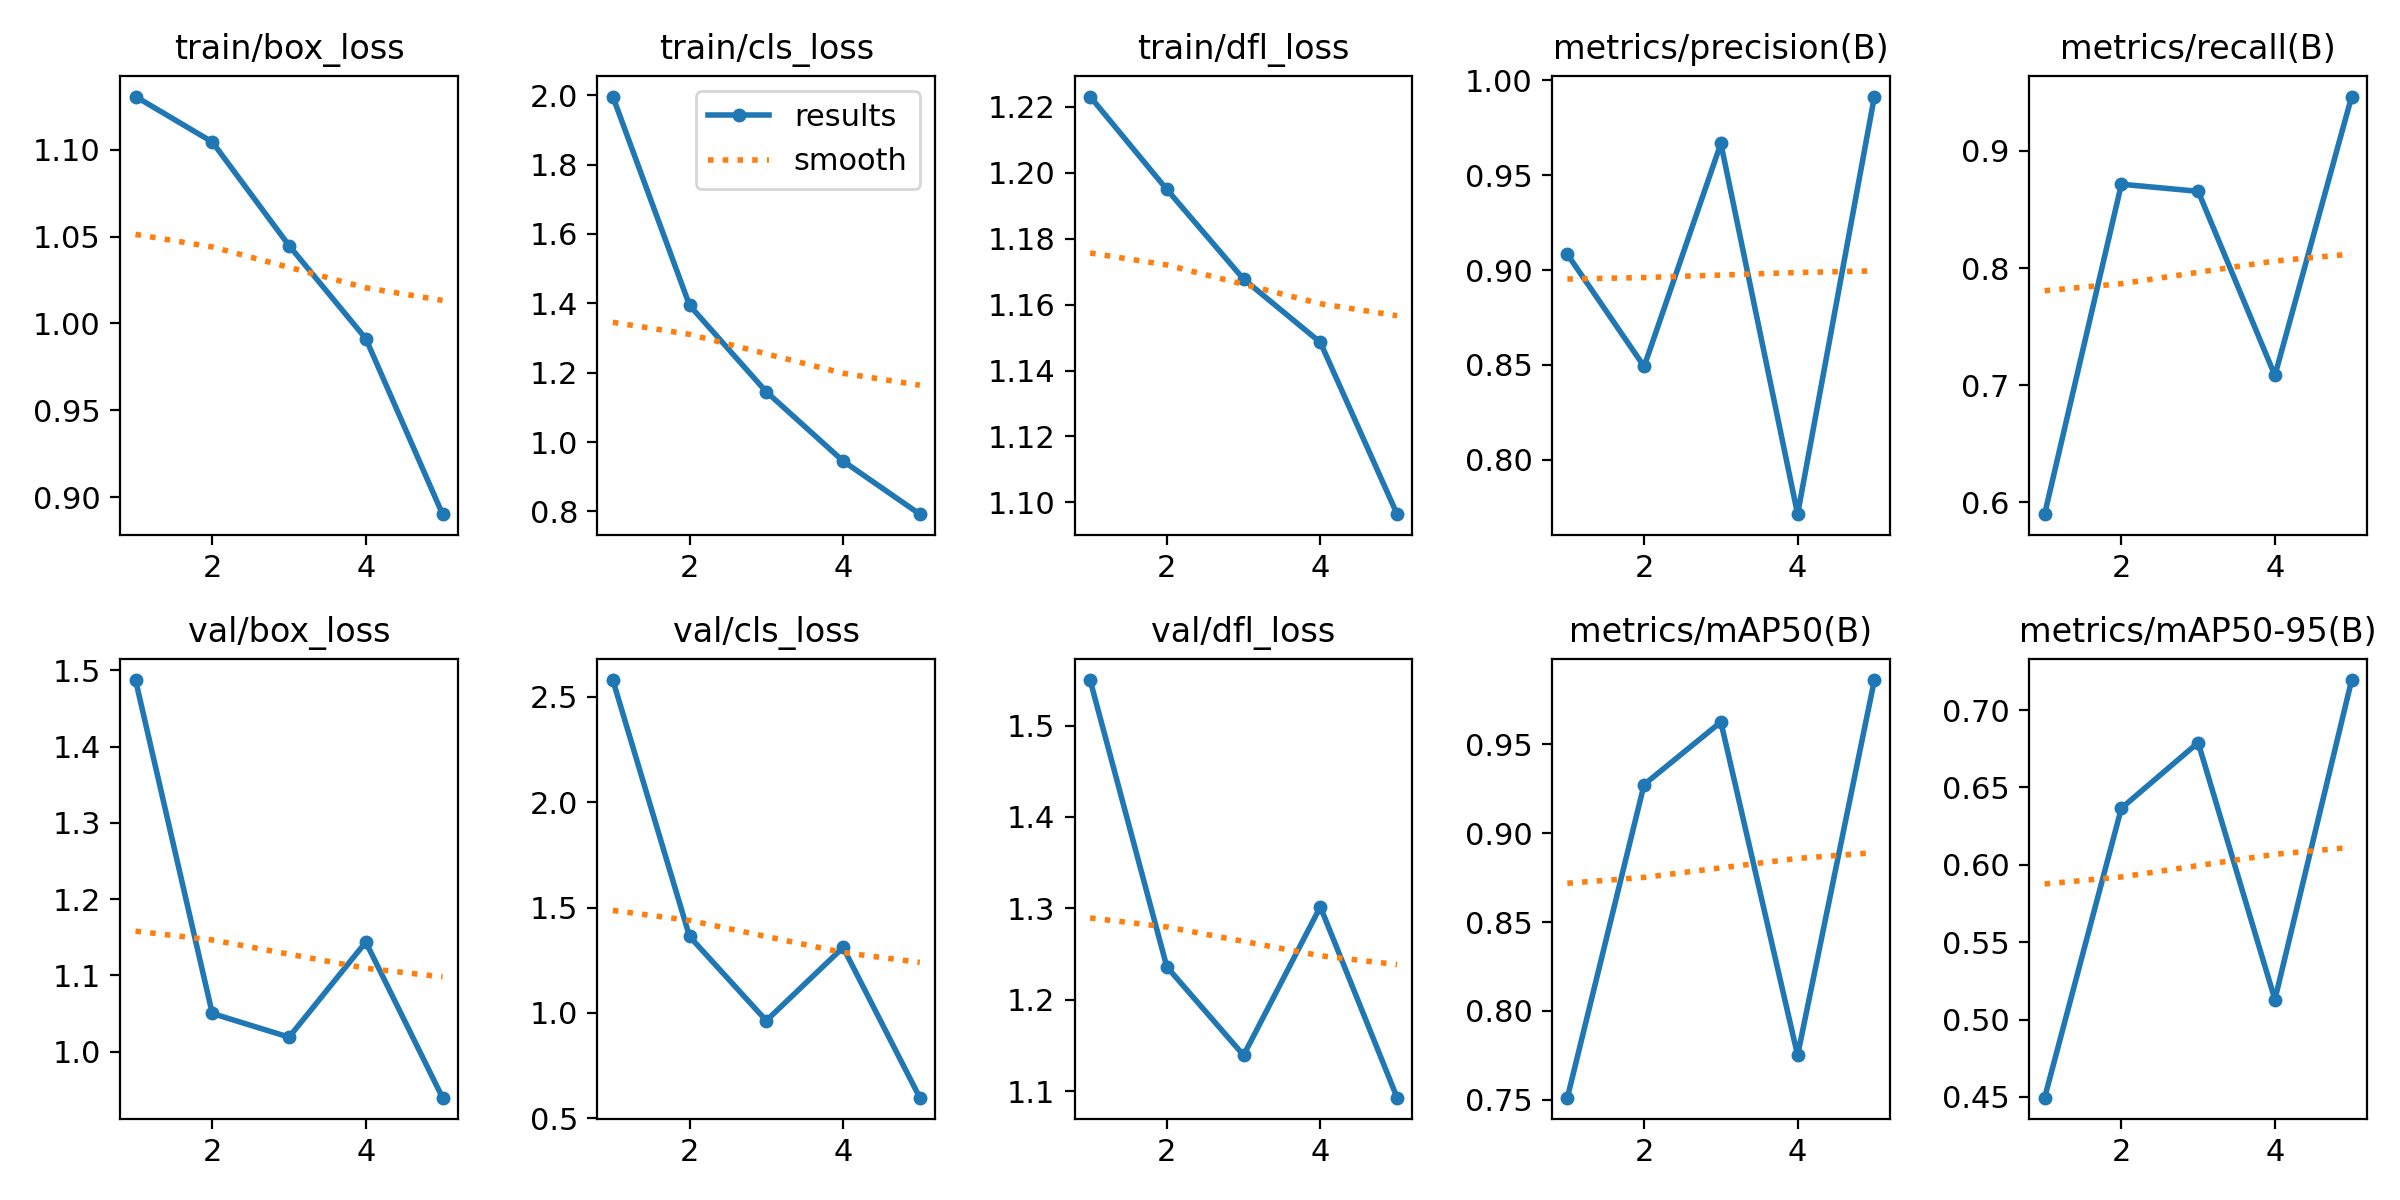

In [10]:
# View a screenshot of the training plots (Loss Function plots / Accuracy)

from IPython.display import Image
Image(filename=f'/content/runs/detect/train/results.png', width=600)

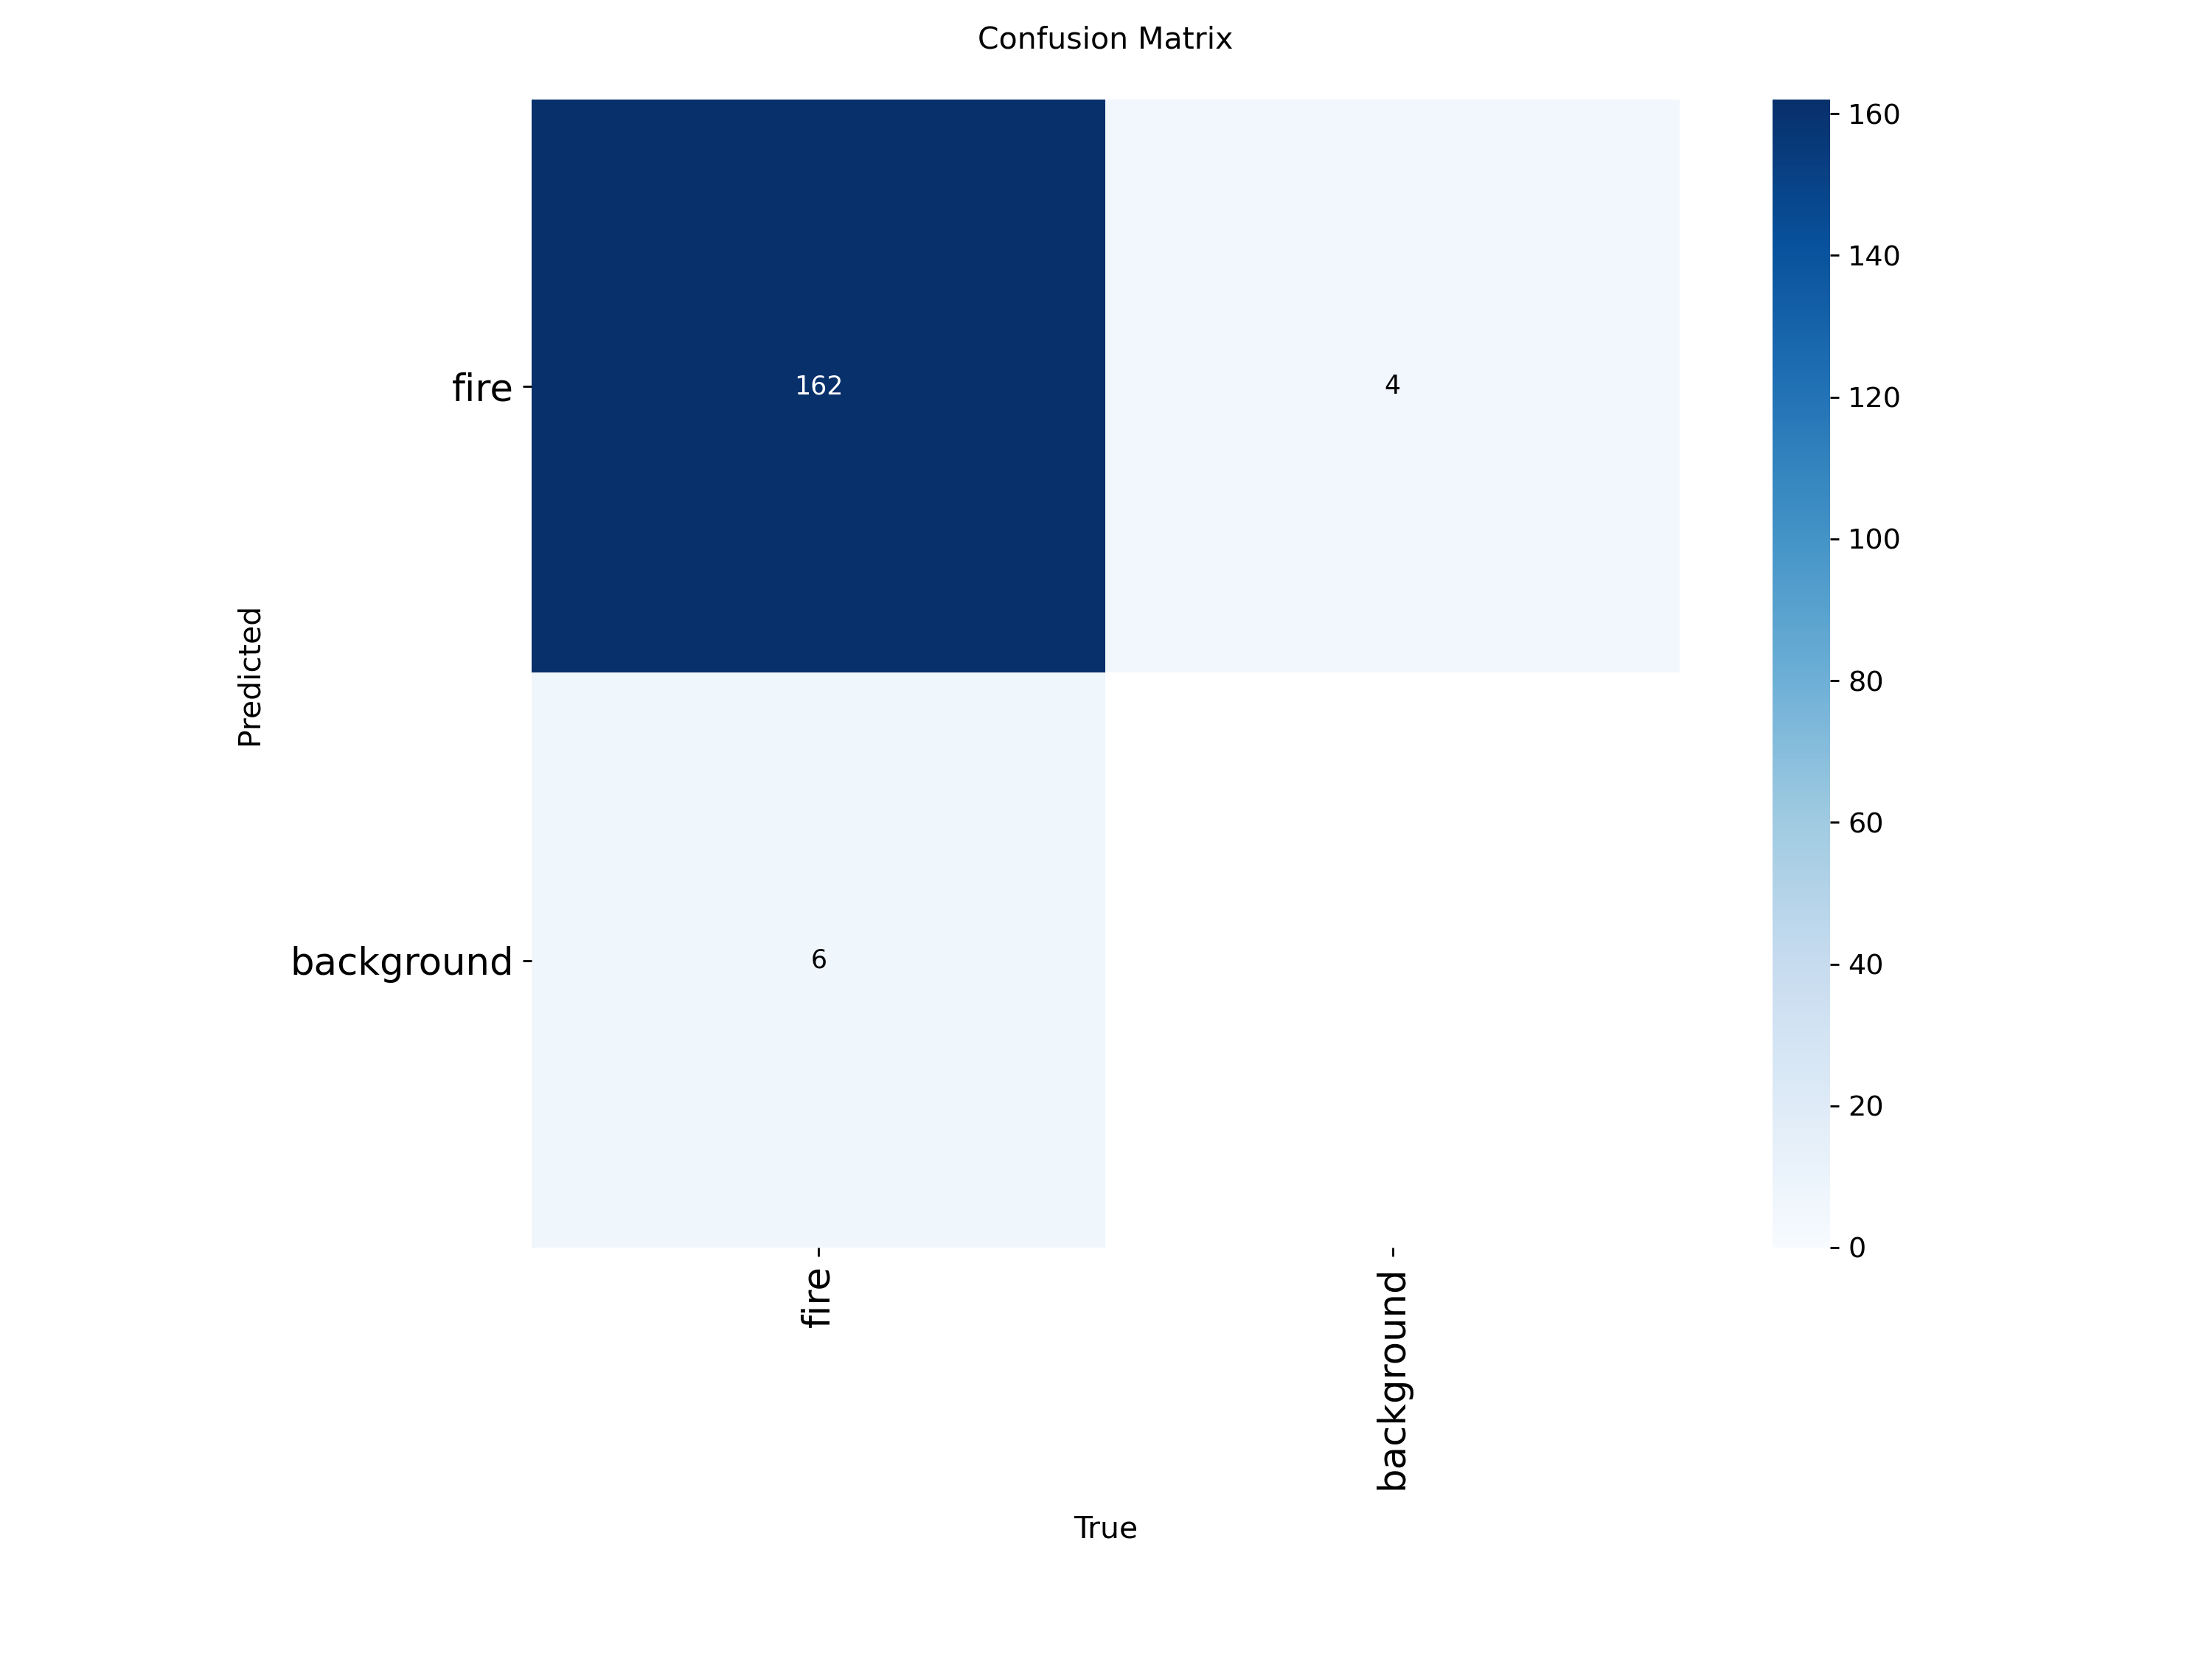

In [12]:
# View a screenshot of the Confusio Matrix

Image(filename=f'/content/runs/detect/train/confusion_matrix.png', width=600)

In [ ]:
# View metrics of the training

model.val(data=DATA_YAML_PATH)